## Sigmoid 函数

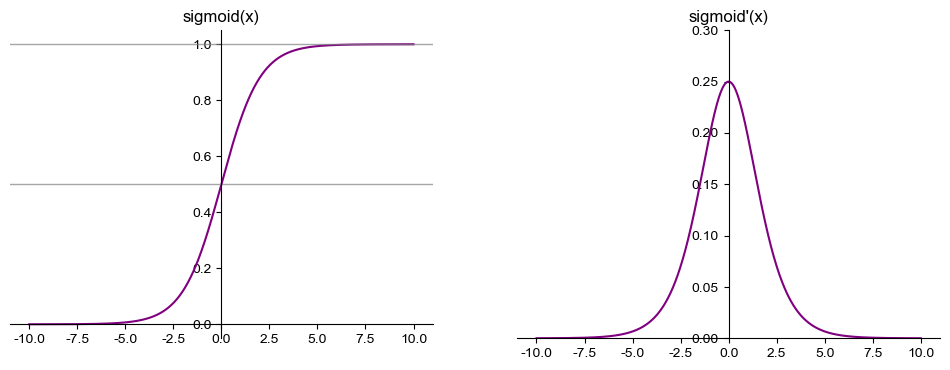

In [7]:
import torch
import matplotlib.pyplot as plt

x = torch.linspace(-10, 10, 1000, requires_grad=True)
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(12, 4)

ax[0].plot(x.data, torch.sigmoid(x).data, "purple")
ax[0].set_title("sigmoid(x)")
ax[0].spines["top"].set_visible(False)
ax[0].spines["right"].set_visible(False)
ax[0].spines["left"].set_position("zero")
ax[0].spines["bottom"].set_position("zero")
ax[0].axhline(0.5, color="gray", alpha=0.7, linewidth=1)
ax[0].axhline(1, color="gray", alpha=0.7, linewidth=1)

torch.sigmoid(x).sum().backward() # 反向传播计算梯度
ax[1].plot(x.data, x.grad, "purple")

ax[1].set_title("sigmoid'(x)")
ax[1].spines["top"].set_visible(False)
ax[1].spines["right"].set_visible(False)
ax[1].spines["left"].set_position("zero")
ax[1].spines["bottom"].set_position("zero")
ax[1].set_ylim(0, 0.3)

plt.show()

## Tanh 函数

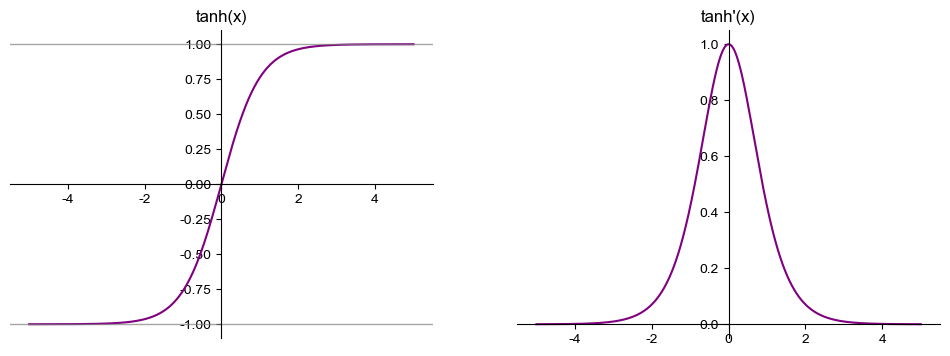

In [8]:
import torch
import matplotlib.pyplot as plt

x = torch.linspace(-5, 5, 1000, requires_grad=True)
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(12, 4)

ax[0].plot(x.data, torch.tanh(x).data, "purple")
ax[0].set_title("tanh(x)")
ax[0].spines["top"].set_visible(False)
ax[0].spines["right"].set_visible(False)
ax[0].spines["left"].set_position("zero")
ax[0].spines["bottom"].set_position("zero")
ax[0].axhline(-1, color="gray", alpha=0.7, linewidth=1)
ax[0].axhline(1, color="gray", alpha=0.7, linewidth=1)

torch.tanh(x).sum().backward() # 反向传播计算梯度
ax[1].plot(x.data, x.grad, "purple")
ax[1].set_title("tanh'(x)")
ax[1].spines["top"].set_visible(False)
ax[1].spines["right"].set_visible(False)
ax[1].spines["left"].set_position("zero")
ax[1].spines["bottom"].set_position("zero")

plt.show()

## ReLU 函数

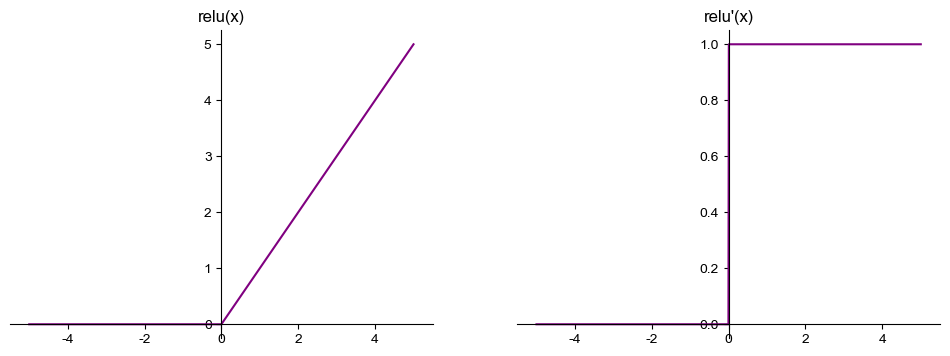

In [11]:
import torch
import matplotlib.pyplot as plt

x = torch.linspace(-5, 5, 1000, requires_grad=True)
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(12, 4)

ax[0].plot(x.data, torch.relu(x).data, "purple")
ax[0].set_title("relu(x)")
ax[0].spines["top"].set_visible(False)
ax[0].spines["right"].set_visible(False)
ax[0].spines["left"].set_position("zero")
ax[0].spines["bottom"].set_position("zero")

torch.relu(x).sum().backward() # 反向传播计算梯度
ax[1].plot(x.data, x.grad, "purple")
ax[1].set_title("relu'(x)")
ax[1].spines["top"].set_visible(False)
ax[1].spines["right"].set_visible(False)
ax[1].spines["left"].set_position("zero")
ax[1].spines["bottom"].set_position("zero")

plt.show()


## Softmax 函数

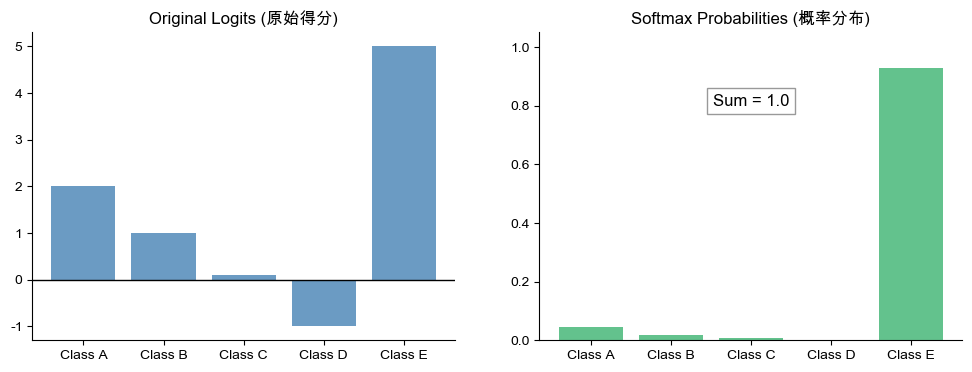

Logits 的梯度 (dLoss/dLogits):
tensor([ 0.0462,  0.0170,  0.0069,  0.0023, -0.0724])


In [9]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# 1. 设置 macOS 支持的中文字体
# 'Arial Unicode MS' 或 'PingFang SC' (苹方) 在 Mac 上通常最管用
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] 

# 2. 解决更换字体后，坐标轴上的负号 '-' 显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

# 1. 准备数据：假设我们有一个模型对 5 个类别的原始输出得分 (Logits)
logits = torch.tensor([2.0, 1.0, 0.1, -1.0, 5.0], requires_grad=True)

# 2. 计算 Softmax
# dim=0 表示在第 0 维度（这里是一维向量）上进行计算
probabilities = torch.softmax(logits, dim=0)

# 3. 准备绘图布局
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(12, 4)
classes = ['Class A', 'Class B', 'Class C', 'Class D', 'Class E']
x_pos = np.arange(len(classes))

# 4. 绘制左图：原始得分 (Logits)
ax[0].bar(x_pos, logits.data.numpy(), color='steelblue', alpha=0.8)
ax[0].set_title("Original Logits (原始得分)")
ax[0].set_xticks(x_pos)
ax[0].set_xticklabels(classes)
ax[0].spines["top"].set_visible(False)
ax[0].spines["right"].set_visible(False)
ax[0].axhline(0, color="black", linewidth=1) # 添加 y=0 的基准线

# 5. 绘制右图：Softmax 概率
ax[1].bar(x_pos, probabilities.data.numpy(), color='mediumseagreen', alpha=0.8)
ax[1].set_title("Softmax Probabilities (概率分布)")
ax[1].set_xticks(x_pos)
ax[1].set_xticklabels(classes)
ax[1].spines["top"].set_visible(False)
ax[1].spines["right"].set_visible(False)
ax[1].set_ylim(0, 1.05) # 概率最大值为 1

# 在右图添加文本，证明概率总和为 1
sum_prob = probabilities.sum().item()
ax[1].text(2, 0.8, f'Sum = {sum_prob:.1f}', ha='center', fontsize=12,
           bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.show()

# 6. 演示反向传播（获取雅可比矩阵的梯度）
# 假设真实标签是 Class E (索引为 4)
# 在实际应用中，我们会配合交叉熵损失函数使用
loss = -torch.log(probabilities[4]) 
loss.backward()

print("Logits 的梯度 (dLoss/dLogits):")
print(logits.grad)